In [6]:
import ipywidgets as widgets
from ipywidgets import Layout
import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS, same_color
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

plt.style.use('seaborn-v0_8-poster')

R = widgets.FloatText(value=4,min=0,max=30,step=.01,description='Major radius')
r = widgets.FloatText(value=1.78,min=0,max=30,step=.01,description='Minor radius')
w = widgets.FloatText(value=.4,min=0,max=5,step=.01,description='Stitch width')
h = widgets.FloatText(value=.4,min=0,max=5,step=.01,description='Stitch height')

def st(w,h): # Stitch of width w and heaight h, modelled as a spheroid, centered at (x0,y0,z_0)
            u = np.linspace(0, np.pi, 10)
            v = np.linspace(0, 2 * np.pi, 10)
            u, v = np.meshgrid(u, v)
            x = (w/2)*np.sin(u)*np.cos(v)
            y = (w/2)*np.sin(u)*np.sin(v)
            z = (h/2)*np.cos(u)
            return x, y, z

def f(R,r,w,h):
    if r>=R:
        pattern=[widgets.HTML(value='Error! Major radius must exceed minor radius')]
    else:
        N = round(r * np.pi/h)
        st_count = [0]*(int(N)+1)
        pattern = [0]*(int(N)+1)
        fig = plt.figure(figsize = (8,8))
        ax = plt.axes(projection='3d')
        ax.grid()
        for n in range(int(N)+1):
            st_count[n]=round(2*np.pi*(R-r*np.cos(n*np.pi/int(N)))/w)
            #if n<10:
            #    print('  Row  ',n,': ',st_count[n],' st')
            #else:
            #    print('  Row ',n,': ',st_count[n],' st')
            pattern[n] = widgets.HBox([widgets.ToggleButton(value=False,description="Row "+str(n)+": "+str(st_count[n])+" st",indent=True)])
           
            for k in range(1,st_count[n]+1):
                theta = (n-.5)*np.pi/N
                phi = (k-.5*n)*2*np.pi/st_count[n] # slight offset to better reflect crochet stitch distribution
                x0 = (R-r*np.cos(theta))*np.cos(phi)
                y0 = (R-r*np.cos(theta))*np.sin(phi)
                z0 = r*np.sin(theta)        
                x = x0 + st(w,h)[0]
                y = y0 + st(w,h)[1]
                z = z0 + st(w,h)[2]
                ax.plot_surface(x, y, z, color=colors[k%10], edgecolor='black', linewidth=.1)
                #ax.plot_surface(x, y, -z, cmap='viridis', edgecolor='black', linewidth=.1)
        
        # Set axes label
        ax.set_xlabel('x', labelpad=20)
        ax.set_ylabel('y', labelpad=20)
        ax.set_zlabel('z', labelpad=20)
        
        ax.set_aspect('equal')
        
        plt.show()
                
    display(widgets.VBox(pattern))


                

out = widgets.interactive_output(f, {'R': R, 'r': r, 'w': w, 'h': h})
#out2 = widgets.interactive_output(g, {'R': R, 'r': r, 'w': w, 'h': h})

pattern_text = widgets.VBox([
    widgets.HTML(value="<b>Upper half:</b> Begin with a foundation chain joined into a loop. Work the stitch counts displayed below in each row. Increases are made using 2 st in st of previous row, evenly distributed for a symmetrical look."),
    widgets.HTML(value="<b>Lower half:</b> Same as upper half, but with first and last rows omitted."),
    widgets.HTML(value="<b>Finishing:</b> Stuff and sew up. Weave in ends.")
])
display(pattern_text)

widgets.VBox(
    [
    widgets.VBox([widgets.HTML(value="<b>Choose pattern dimensions (cm):"), R, r, w, h]),
    widgets.VBox([widgets.HTML(value="<b>Stitch count per row:"),out])
    ],
    layout=Layout(display='flex',justify_content='space-around')
)

N =  14


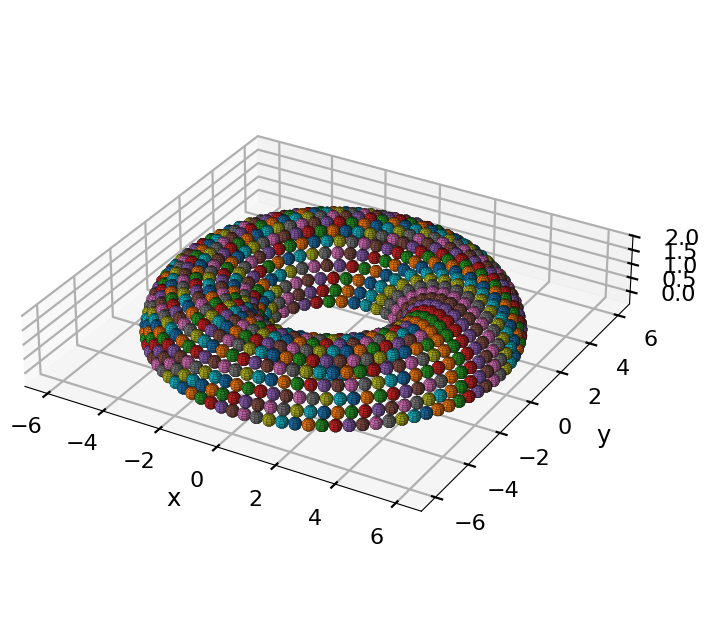

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Feb 17 07:43:11 2026

@author: smp17rjs
"""

import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS, same_color
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

plt.style.use('seaborn-v0_8-poster')

R = 4
r = 1.78255
w = .4
h = .4 # note h=w - non-square stitch case yet to be tested.
N = round(r*np.pi/h)
print("N = ",N)

def st(w,h): # Stitch of width w and heaight h, modelled as a spheroid, centered at (x0,y0,z_0)
    u = np.linspace(0, np.pi, 10)
    v = np.linspace(0, 2 * np.pi, 10)
    u, v = np.meshgrid(u, v)
    x = (w/2)*np.sin(u)*np.cos(v)
    y = (w/2)*np.sin(u)*np.sin(v)
    z = (h/2)*np.cos(u)
    return x, y, z


fig = plt.figure(figsize = (8,8))
ax = plt.axes(projection='3d')
ax.grid()

st_cnt = []
st = st(w,h)

for n in range(0,N+1):
    theta = (n-.5)*np.pi/N
    # Stitch count in row n
    st_cnt = round(2*np.pi*(R-r*np.cos(theta))/w)
    #cos_theta = np.cos(theta)
    #circumference = 2*np.pi*(R-r*np.cos(n*np.pi/N))
    #print("Stitch count: ", st_cnt[n],"\t theta: ", theta, "\t cos(theta): ", cos_theta,"\t Circumference: ", circumference)
    for k in range(1,st_cnt+1):
        phi = (k-.5*n)*2*np.pi/st_cnt # slight offset to better reflect crochet stitch distribution
        x0 = (R-r*np.cos(theta))*np.cos(phi)
        y0 = (R-r*np.cos(theta))*np.sin(phi)
        z0 = r*np.sin(theta)        
        x = x0 + st[0]
        y = y0 + st[1]
        z = z0 + st[2]
        ax.plot_surface(x, y, z, color=colors[k%10], edgecolor='black', linewidth=.1)
        #ax.plot_surface(x, y, -z, cmap='viridis', edgecolor='black', linewidth=.1)

# Set axes label
ax.set_xlabel('x', labelpad=20)
ax.set_ylabel('y', labelpad=20)
ax.set_zlabel('z', labelpad=20)

ax.set_aspect('equal')

plt.show()

In [17]:
%matplotlib ipympl
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import ipywidgets as widgets
from ipywidgets import Layout
from matplotlib.colors import TABLEAU_COLORS, same_color
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

R = widgets.FloatText(value=4,min=0,max=30,step=.01,description='Major radius')
r = widgets.FloatText(value=1.78,min=0,max=30,step=.01,description='Minor radius')
w = widgets.FloatText(value=.4,min=0,max=5,step=.01,description='Stitch width')
h = widgets.FloatText(value=.4,min=0,max=5,step=.01,description='Stitch height')


def f(R,r,w,h):
    if r>=R:
        pattern=[widgets.HTML(value='Error! Major radius must exceed minor radius')]
    else:
        N = round(r * np.pi/h)
        st_count = [0]*(int(N)+1)
        pattern = [0]*(int(N)+1)
        for n in range(int(N)+1):
            st_count[n]=round(2*np.pi*(R-r*np.cos(n*np.pi/int(N)))/w)
            #if n<10:
            #    print('  Row  ',n,': ',st_count[n],' st')
            #else:
            #    print('  Row ',n,': ',st_count[n],' st')
            pattern[n] = widgets.HBox([widgets.ToggleButton(value=False,description="Row "+str(n)+": "+str(st_count[n])+" st",indent=True)])
    #display(widgets.VBox(pattern))
    
    
    #PLOTTING
    plt.style.use('seaborn-v0_8-poster')
    # Plot crocheted(?) torus
    ax = plt.figure().add_subplot(projection='3d')
    ax.view_init(elev=28, azim=60, roll=0)
    for n in range(N+1):
        # Create a grid of the u and v values for row n
        u = np.linspace((n-.5)*np.pi/N, (n+.5)*np.pi/N, 4)
        u0=(n-.5)*np.pi/N
        v = np.linspace(0, 2 * np.pi, st_count[n]+1)
        v0 = 0
        v1 = 2*np.pi*(1-1/(st_count[n]+1))
        x0 = (R - r * np.cos(u0)) * np.cos(v0)
        y0 = (R - r * np.cos(u0)) * np.sin(v0)
        z0 = r * np.sin(u0)
        x1 = (R - r * np.cos(u0)) * np.cos(v1)
        y1 = (R - r * np.cos(u0)) * np.sin(v1)
        z1 = r * np.sin(u0)
        width = np.sqrt((x0-x1)**2+(y0-y1)**2+(z0-z1)**2)
        #print(v)
        print('Row ',n,': ',st_count[n],' st,\t len(v)=',len(v),'\t Rectangle width:',width,'\t Circumference error: ',2*np.pi*(R-r*np.cos(n*np.pi/N))-st_count[n]*.4)
        u, v = np.meshgrid(u, v)
        x = (R - r * np.cos(u)) * np.cos(v)
        y = (R - r * np.cos(u)) * np.sin(v)
        z = r * np.sin(u)
        ax.plot_surface(x, y, z,color=colors[n%10], edgecolor='black', linewidth=.1, alpha=.5)
    
    # Axis limits
    ax.set(zlim=(-R-r,R+r))
    
    # Set axes label
    ax.set_xlabel('x', labelpad=20)
    ax.set_ylabel('y', labelpad=20)
    ax.set_zlabel('z', labelpad=20)
    
    plt.show()

out = widgets.interactive_output(f, {'R': R, 'r': r, 'w': w, 'h': h})


pattern_text = widgets.VBox([
    widgets.HTML(value="<b>Upper half:</b> Begin with a foundation chain joined into a loop. Work the stitch counts displayed below in each row. Increases are made using 2 st in st of previous row, evenly distributed for a symmetrical look."),
    widgets.HTML(value="<b>Lower half:</b> Same as upper half, but with first and last rows omitted."),
    widgets.HTML(value="<b>Finishing:</b> Stuff and sew up. Weave in ends.")
])
display(pattern_text)

widgets.VBox(
    [
        widgets.VBox([widgets.HTML(value="<b>Choose pattern dimensions (cm):"), R, r, w, h]),
        widgets.VBox([widgets.HTML(value="<b>Stitch count per row:"),out])
    ],
    layout=Layout(display='flex',justify_content='space-around')
)



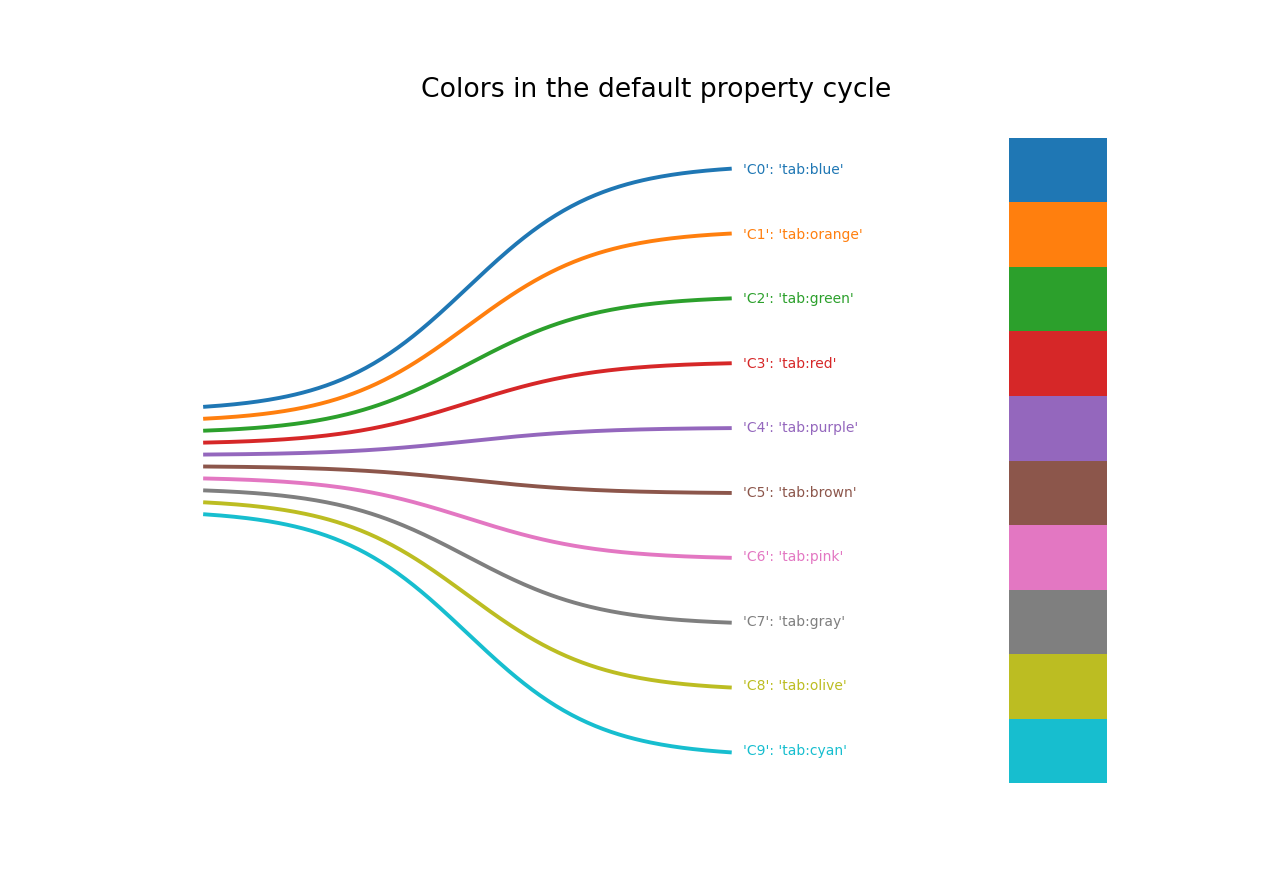

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


4

In [14]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import TABLEAU_COLORS, same_color


def f(x, a):
    """A nice sigmoid-like parametrized curve, ending approximately at *a*."""
    return 0.85 * a * (1 / (1 + np.exp(-x)) + 0.2)


fig, ax = plt.subplots()
ax.axis('off')
ax.set_title("Colors in the default property cycle")

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
x = np.linspace(-4, 4, 200)

for i, (color, color_name) in enumerate(zip(colors, TABLEAU_COLORS)):
    assert same_color(color, color_name)
    pos = 4.5 - i
    ax.plot(x, f(x, pos))
    ax.text(4.2, pos, f"'C{i}': '{color_name}'", color=color, va="center")
    ax.bar(9, 1, width=1.5, bottom=pos-0.5)

plt.show()
print(colors)
14 %10